# v2 Method Benchmark: Full Basic Model with Adjustment Costs

Compares **PFI**, **LR**, **ER**, **BRM**, and **SHAC** in the full basic
investment model with non-zero convex and fixed adjustment costs.

Training uses **temperature annealing**, but every benchmark metric is
evaluated at a fixed **temperature = 1e-6** so checkpoint comparisons stay
comparable while the indicator gate hardens.


---
# Section 0: Setup


In [1]:
import sys, os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-codex")

import math
import time
from dataclasses import replace

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import RegularGridInterpolator

sys.path.append(os.path.abspath(".."))

from src.v2.benchmarks import (
    build_action_grid_policy,
    load_manifest,
    load_method_bundle,
    load_named_dataset,
    load_pfi_bundle,
    prepare_benchmark_run,
    restore_selected_models,
    restore_selected_snapshot,
    save_figure,
    save_manifest_sections,
    save_method_bundle,
    save_named_dataset,
    save_pfi_bundle,
    save_plot_inputs,
    save_summary_rows,
)
from src.v2.data.generator import DataGenerator, DataGeneratorConfig
from src.v2.environments.basic_investment import (
    BasicInvestmentEnv, EconomicParams, ShockParams,
    compute_frictionless_policy,
)
from src.v2.networks.policy import PolicyNetwork
from src.v2.networks.state_value import StateValueNetwork
from src.v2.solvers import solve_pfi, PFIConfig, GridConfig
from src.v2.trainers.brm import train_brm
from src.v2.trainers.config import LRConfig, ERConfig, BRMConfig, SHACConfig
from src.v2.trainers.er import train_er
from src.v2.trainers.lr import train_lr
from src.v2.trainers.shac import train_shac
from src.v2.utils.annealing import AnnealingSchedule
from src.v2.utils.seeding import fold_in_seed, seed_runtime

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")


/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow 2.16.2
GPU available: True


In [2]:
TRAINING_PROFILE = "FAST_DEBUG"  # "FAST_DEBUG" | "BALANCED"

SAVE_RUN = True
LOAD_RUN_DIR = None  # e.g. "results/v2_04_benchmark_full_basic/latest"
RUN_TAG = None
RECOMPUTE_LOADED_METRICS = False
SNAPSHOT_TARGETS = ("policy",)

PROFILE_SETTINGS = {
    "FAST_DEBUG": {
        "anneal_fraction": 0.4,
        "stop_patience": 2,
        "benchmark_policy_mae_abs_delta": 5.0,
        "benchmark_policy_mae_rel_delta": 0.10,
        "target_eval_seconds": 5.0,
        "safety_cap_seconds": 10 * 60,
    },
    "BALANCED": {
        "anneal_fraction": 0.75,
        "stop_patience": 4,
        "benchmark_policy_mae_abs_delta": 1.0,
        "benchmark_policy_mae_rel_delta": 0.01,
        "target_eval_seconds": 10.0,
        "safety_cap_seconds": 60 * 60,
    },
}[TRAINING_PROFILE]

EVAL_TEMP = 1e-6
ANNEAL_INIT_TEMP = 1.0
ANNEAL_BUFFER = 0.25
ANNEAL_FRACTION = PROFILE_SETTINGS["anneal_fraction"]
STOP_PATIENCE = PROFILE_SETTINGS["stop_patience"]
BENCHMARK_POLICY_MAE_ABS_DELTA = PROFILE_SETTINGS["benchmark_policy_mae_abs_delta"]
BENCHMARK_POLICY_MAE_REL_DELTA = PROFILE_SETTINGS["benchmark_policy_mae_rel_delta"]
TARGET_EVAL_SECONDS = PROFILE_SETTINGS["target_eval_seconds"]
STEP_CAP_BUFFER = 1.5

CALIBRATION_STEPS = 20
CALIBRATION_INTERVAL = 5
CALIBRATION_TAIL_POINTS = 3

SAFETY_CAP_SECONDS = PROFILE_SETTINGS["safety_cap_seconds"]
N_PATHS = {"FAST_DEBUG": 1000, "BALANCED": 5000}[TRAINING_PROFILE]
HORIZON_DATA = 256
MASTER_SEED = (20, 26)
STRICT_REPRODUCIBILITY = False

N_LAYERS = 5
N_NEURONS = 64
LR_HORIZON = 32

EVAL_HORIZON = 150
EVAL_TRAJ_SAMPLES = 1000
PFI_GAP_SAMPLES = {"FAST_DEBUG": 5000, "BALANCED": 20000}[TRAINING_PROFILE]

PFI_BENCHMARK_GRID = {
    "FAST_DEBUG": (60, 60, 600),
    "BALANCED": (125, 125, 2000),
}[TRAINING_PROFILE]
PFI_MAX_ITER = 200
PFI_EVAL_STEPS = 800

METHOD_ORDER = ["LR", "ER", "BRM", "SHAC"]
METHOD_COLORS = {
    "PFI": "black",
    "LR": "steelblue",
    "ER": "darkorange",
    "BRM": "seagreen",
    "SHAC": "slateblue",
}

RUN = prepare_benchmark_run(
    "v2_04_benchmark_full_basic",
    save_run=SAVE_RUN,
    load_run_dir=LOAD_RUN_DIR,
    results_root="results",
    run_tag=RUN_TAG,
)

print(f"Profile: {TRAINING_PROFILE}")
print(f"Benchmark evaluation temperature: {EVAL_TEMP:.0e}")
print(f"Annealing target fraction of budget: {ANNEAL_FRACTION:.2f}")
print(f"Stopping patience: {STOP_PATIENCE} eval checkpoints")
print(
    "Benchmark-policy plateau tolerance: "
    f"abs={BENCHMARK_POLICY_MAE_ABS_DELTA:.4g}, "
    f"rel={BENCHMARK_POLICY_MAE_REL_DELTA:.2%}"
)
print(f"Target eval spacing: ~{TARGET_EVAL_SECONDS:.0f}s")
print(f"Safety cap: {SAFETY_CAP_SECONDS/60:.0f} min per method")
print(f"Snapshot targets: {SNAPSHOT_TARGETS}")
print(f"PFI benchmark grid: {PFI_BENCHMARK_GRID}")
print(f"Strict reproducibility mode: {STRICT_REPRODUCIBILITY}")
print(f"Run mode: {RUN['mode']}")
if RUN["run_dir"] is not None:
    print(f"Run dir: {RUN['run_dir']}")


Profile: FAST_DEBUG
Benchmark evaluation temperature: 1e-06
Annealing target fraction of budget: 0.40
Stopping patience: 2 eval checkpoints
Benchmark-policy plateau tolerance: abs=5, rel=10.00%
Target eval spacing: ~5s
Safety cap: 10 min per method
Snapshot targets: ('policy',)
PFI benchmark grid: (60, 60, 600)
Strict reproducibility mode: False
Run mode: save
Run dir: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/docs/results/v2_04_benchmark_full_basic/20260318-221345


---
# Section 1: Environment & Data


In [3]:
full_params = EconomicParams(
    interest_rate=0.04,     
    depreciation_rate=0.15,
    production_elasticity=0.7,
    cost_convex=0.2, cost_fixed=0.02,
)
shock_params = ShockParams(mu=0.0, rho=0.7, sigma=0.15)

env_eval = BasicInvestmentEnv(econ_params=full_params, shock_params=shock_params)

print("BasicInvestmentEnv (full adjustment costs)")
print(f"  cost_convex: {full_params.cost_convex:.4f}")
print(f"  cost_fixed:  {full_params.cost_fixed:.4f}")
print(f"  Discount:    {env_eval.discount():.4f}")
print(f"  k in [{env_eval.k_min:.2f}, {env_eval.k_max:.2f}]")
print(f"  I in [{env_eval.I_min:.2f}, {env_eval.I_max:.2f}]")
print(f"  Action grid mode: {env_eval.grid_spec()['action'][0].spacing}")

if RUN["mode"] == "load":
    train_traj = None
    train_flat = None
    val_traj = load_named_dataset(RUN, "val_traj", fmt="trajectory")
    val_flat = load_named_dataset(RUN, "val_flat", fmt="flat")
    pfi_gap_flat = load_named_dataset(RUN, "pfi_gap_flat", fmt="flat")
    print(f"Loaded evaluation datasets from {RUN['run_dir']}")
else:
    gen_config = DataGeneratorConfig(
        n_paths=N_PATHS,
        horizon=HORIZON_DATA,
        master_seed=MASTER_SEED,
    )
    gen = DataGenerator(env_eval, gen_config)

    train_traj = gen.get_trajectory_dataset("train")
    train_flat = gen.get_flattened_dataset("train")
    val_traj = gen.get_trajectory_dataset("val")
    val_flat = gen.get_flattened_dataset("val")
    pfi_gap_flat = {k: v[:PFI_GAP_SAMPLES] for k, v in val_flat.items()}

    save_named_dataset(
        RUN, "val_traj", val_traj, fmt="trajectory",
        env_config={"econ_params": full_params, "shock_params": shock_params},
        generator_config=gen_config,
    )
    save_named_dataset(
        RUN, "val_flat", val_flat, fmt="flat",
        env_config={"econ_params": full_params, "shock_params": shock_params},
        generator_config=gen_config,
    )
    save_named_dataset(
        RUN, "pfi_gap_flat", pfi_gap_flat, fmt="flat",
        env_config={"econ_params": full_params, "shock_params": shock_params},
        generator_config=gen_config,
    )
    save_manifest_sections(
        RUN,
        setup={
            "training_profile": TRAINING_PROFILE,
            "master_seed": list(MASTER_SEED),
            "strict_reproducibility": STRICT_REPRODUCIBILITY,
            "save_run": SAVE_RUN,
            "load_run_dir": LOAD_RUN_DIR,
            "snapshot_targets": list(SNAPSHOT_TARGETS),
        },
        benchmark={
            "eval_temperature": EVAL_TEMP,
            "anneal_init_temp": ANNEAL_INIT_TEMP,
            "anneal_buffer": ANNEAL_BUFFER,
            "anneal_fraction": ANNEAL_FRACTION,
            "stop_patience": STOP_PATIENCE,
            "benchmark_policy_mae_abs_delta": BENCHMARK_POLICY_MAE_ABS_DELTA,
            "benchmark_policy_mae_rel_delta": BENCHMARK_POLICY_MAE_REL_DELTA,
            "target_eval_seconds": TARGET_EVAL_SECONDS,
            "step_cap_buffer": STEP_CAP_BUFFER,
            "safety_cap_seconds": SAFETY_CAP_SECONDS,
            "eval_horizon": EVAL_HORIZON,
            "eval_traj_samples": EVAL_TRAJ_SAMPLES,
            "pfi_gap_samples": PFI_GAP_SAMPLES,
            "pfi_grid": list(PFI_BENCHMARK_GRID),
            "pfi_max_iter": PFI_MAX_ITER,
            "pfi_eval_steps": PFI_EVAL_STEPS,
        },
        env={"econ_params": full_params, "shock_params": shock_params},
    )

print(f"Validation trajectories: {val_traj['s_endo_0'].shape[0]} paths")
print(f"Validation flat states: {val_flat['s_endo'].shape[0]}")
if train_traj is not None:
    print(f"Training trajectories: {train_traj['s_endo_0'].shape[0]} paths")


BasicInvestmentEnv (full adjustment costs)
  cost_convex: 0.2000
  cost_fixed:  0.0200
  Discount:    0.9615
  k in [20.05, 481.12]
  I in [-388.90, 464.08]
  Action grid mode: zero_power
Validation trajectories: 1000 paths
Validation flat states: 256000
Training trajectories: 1000 paths


---
# Section 2: Helpers

Environment factories, calibration, annealing-rate derivation, PFI interpolation,
fixed-temperature checkpoint evaluation, and slice diagnostics.


In [4]:
def make_training_env(decay_rate=None):
    env = BasicInvestmentEnv(econ_params=full_params, shock_params=shock_params)
    if decay_rate is not None:
        def schedule_factory(_decay=decay_rate):
            return AnnealingSchedule(
                init_temp=ANNEAL_INIT_TEMP,
                min_temp=EVAL_TEMP,
                decay_rate=_decay,
                buffer=ANNEAL_BUFFER,
            )
        env.annealing_schedule = schedule_factory
    return env


def derived_seed(*tokens):
    return fold_in_seed(MASTER_SEED, *tokens)


def seed_experiment(*tokens):
    return seed_runtime(
        MASTER_SEED, *tokens,
        strict_reproducibility=STRICT_REPRODUCIBILITY,
    )


def make_policy(env, name="policy", seed=None):
    net = PolicyNetwork(
        state_dim=env.state_dim(), action_dim=env.action_dim(),
        **env.action_spec(), n_layers=N_LAYERS, n_neurons=N_NEURONS,
        seed=seed, name=name)
    net(tf.zeros((1, env.state_dim())))
    return net


def make_value_net(env, name="value_net", seed=None):
    net = StateValueNetwork(
        state_dim=env.state_dim(), n_layers=N_LAYERS, n_neurons=N_NEURONS,
        seed=seed, name=name)
    net(tf.zeros((1, env.state_dim())))
    return net


def sanitize_config(base_config, **updates):
    payload = dict(
        monitor=None,
        mode="min",
        threshold=None,
        stop_patience=1,
        stop_min_delta=0.0,
        stop_rel_delta=0.0,
        min_steps_before_stop=0,
        max_wall_time_sec=None,
        weight_history=None,
        checkpoint_history=None,
        snapshot_targets=("policy",),
    )
    payload.update(updates)
    return replace(base_config, **payload)


def estimate_steady_step_cost(history, wall_time_sec):
    steps = np.asarray(history["step"], dtype=np.float64)
    elapsed = np.asarray(history["elapsed_sec"], dtype=np.float64)
    if steps.size >= 2:
        tail = min(CALIBRATION_TAIL_POINTS, steps.size)
        steps_tail = steps[-tail:]
        elapsed_tail = elapsed[-tail:]
        step_span = steps_tail[-1] - steps_tail[0]
        elapsed_span = elapsed_tail[-1] - elapsed_tail[0]
        if step_span > 0 and elapsed_span > 0:
            return elapsed_span / step_span
    total_steps = max(int(steps[-1]) + 1 if steps.size else 1, 1)
    return wall_time_sec / total_steps


def calibrate_time_per_step(label, train_fn, make_nets_fn, datasets, base_config):
    env_cal = make_training_env()
    seed_experiment("calibration", label)
    measure_config = sanitize_config(
        base_config,
        n_steps=CALIBRATION_STEPS,
        eval_interval=CALIBRATION_INTERVAL,
    )
    measure_nets = make_nets_fn(env_cal)
    measured = train_fn(env_cal, *measure_nets, *datasets, config=measure_config)
    t_per_step = estimate_steady_step_cost(measured["history"], measured["wall_time_sec"])
    eval_interval = max(int(round(TARGET_EVAL_SECONDS / max(t_per_step, 1e-8))), 1)
    n_step_cap = max(int(np.ceil(SAFETY_CAP_SECONDS / max(t_per_step, 1e-8) * STEP_CAP_BUFFER)), 1)
    return {
        "t_per_step": t_per_step,
        "eval_interval": eval_interval,
        "n_step_cap": n_step_cap,
    }


def derive_decay_rate(target_n_anneal, init_temp=ANNEAL_INIT_TEMP,
                      min_temp=EVAL_TEMP, buffer=ANNEAL_BUFFER):
    target_n_anneal = max(int(target_n_anneal), 1)
    effective_n = target_n_anneal / (1.0 + buffer)
    effective_n = max(effective_n, 1.0)
    return float(np.exp((np.log(min_temp) - np.log(init_temp)) / effective_n))


def state_points_from_flat(dataset):
    z = dataset["z"].numpy().reshape(-1)
    k = dataset["s_endo"].numpy().reshape(-1)
    return np.column_stack([z, k])


def persist_figure(fig, filename):
    save_figure(RUN, fig, filename)


def persist_method(name):
    entry = results[name]
    save_method_bundle(
        RUN,
        name,
        result=entry.get("result"),
        checkpoint_history=entry.get("checkpoint_history"),
        weight_history=entry.get("weight_history"),
        checkpoint_metrics=entry.get("checkpoint_metrics"),
        selected=entry.get("selected"),
        extra_sections={
            "name": entry.get("name", name),
            "n_anneal": entry.get("n_anneal"),
            "stop_enable_step": entry.get("stop_enable_step"),
            "calibration": entry.get("calibration"),
            "anneal_elapsed_sec": entry.get("anneal_elapsed_sec"),
            "snapshot_targets": list(entry.get("snapshot_targets", SNAPSHOT_TARGETS)),
        },
    )


def anneal_floor_reached(train_temperature, target=EVAL_TEMP, rel_tol=1e-6):
    return float(train_temperature) <= float(target) * (1.0 + rel_tol)


def anneal_ready_indices(metrics, fallback_step=0):
    steps = list(metrics.get("step", []))
    temps = list(metrics.get("train_temperature", []))
    ready = [
        idx for idx, temp in enumerate(temps)
        if anneal_floor_reached(temp)
    ]
    if ready:
        return ready
    if fallback_step > 0:
        ready = [idx for idx, step in enumerate(steps) if int(step) + 1 >= int(fallback_step)]
        if ready:
            return ready
    return list(range(len(steps)))


def restore_entry_at_step(entry, step):
    checkpoint_history = entry.get("checkpoint_history") or []
    if checkpoint_history:
        snapshot_targets = tuple(entry.get("snapshot_targets", SNAPSHOT_TARGETS))
        models = {}
        if "policy" in snapshot_targets and entry.get("policy") is not None:
            models["policy"] = entry["policy"]
        if "value_net" in snapshot_targets and entry.get("value_net") is not None:
            models["value_net"] = entry["value_net"]
        if not models:
            raise ValueError(
                f"No restorable models found for snapshot targets {snapshot_targets}."
            )
        restore_selected_models(models, checkpoint_history, step)
        return
    restore_selected_snapshot(entry["policy"], entry["weight_history"], step)


def load_saved_method(name):
    entry = load_method_bundle(RUN, name)
    policy = make_policy(env_eval, name=f"policy_{name.lower()}", seed=derived_seed("training", name, "policy"))

    checkpoint_history = entry.get("checkpoint_history") or []
    has_value_snapshot = any(
        "value_net" in item.get("models", {}) for item in checkpoint_history
    )
    value_net = None
    if has_value_snapshot:
        value_net = make_value_net(
            env_eval,
            name=f"value_net_{name.lower()}",
            seed=derived_seed("training", name, "value"),
        )

    if entry.get("selected") is not None:
        restore_entry_at_step(
            {**entry, "policy": policy, "value_net": value_net},
            entry["selected"]["selected_step"],
        )
    elif checkpoint_history:
        restore_entry_at_step(
            {**entry, "policy": policy, "value_net": value_net},
            checkpoint_history[-1]["step"],
        )
    elif entry["weight_history"]:
        policy.set_weights(entry["weight_history"][-1][1])

    entry["policy"] = policy
    if value_net is not None:
        entry["value_net"] = value_net
    entry["name"] = entry["result"].get("name", name)
    entry["n_anneal"] = int(entry["result"].get("n_anneal", 0) or 0)
    entry["calibration"] = entry["result"].get("calibration")
    entry["stop_enable_step"] = int(
        entry["result"].get(
            "stop_enable_step",
            (entry["calibration"] or {}).get("stop_enable_step", entry["n_anneal"]),
        )
        or 0
    )
    entry["snapshot_targets"] = tuple(entry["result"].get("snapshot_targets", SNAPSHOT_TARGETS))
    if entry.get("checkpoint_metrics") is not None:
        entry["checkpoint_index"] = {
            int(step): idx for idx, step in enumerate(entry["checkpoint_metrics"]["step"])
        }
        ready = anneal_ready_indices(
            entry["checkpoint_metrics"],
            fallback_step=entry["stop_enable_step"],
        )
        entry["anneal_elapsed_sec"] = (
            entry["checkpoint_metrics"]["elapsed_sec"][ready[0]]
            if ready else entry["result"].get("anneal_elapsed_sec")
        )
    else:
        entry["anneal_elapsed_sec"] = entry["result"].get("anneal_elapsed_sec")
    return entry


def build_pfi_policy(result):
    exo_1d = result["grids"]["exo_grids_1d"][0]
    endo_1d = result["grids"]["endo_grids_1d"][0]

    action_grid = result["policy_action"][:, :, 0].numpy()
    kprime_grid = result["policy_endo"][:, :, 0].numpy()

    action_policy = build_action_grid_policy(result, env_eval.action_dim())
    kprime_interp = RegularGridInterpolator(
        (exo_1d, endo_1d), kprime_grid,
        method="linear", bounds_error=False, fill_value=None)

    return action_policy, kprime_interp


def evaluate_implied_value(env, policy, traj_dataset, horizon=EVAL_HORIZON,
                           n_samples=EVAL_TRAJ_SAMPLES, temperature=EVAL_TEMP,
                           gate_mode="hard"):
    gamma = env.discount()
    s_endo_0 = traj_dataset["s_endo_0"][:n_samples]
    z_path = traj_dataset["z_path"][:n_samples]
    T = min(horizon, z_path.shape[1] - 1)

    k = s_endo_0
    total_reward = tf.zeros(tf.shape(k)[0])
    discount_t = 1.0

    for t in range(T):
        z_t = z_path[:, t, :]
        s_t = env.merge_state(k, z_t)
        a_t = policy(s_t, training=False)
        r_t = tf.reshape(
            env.reward(s_t, a_t, temperature=temperature, gate_mode=gate_mode),
            [-1],
        )
        total_reward = total_reward + discount_t * r_t
        k = env.endogenous_transition(k, a_t, z_t)
        discount_t = discount_t * gamma

    return float(tf.reduce_mean(total_reward))


def evaluate_benchmark_policy_mae(env, policy, flat_dataset, benchmark_kprime_interp):
    s = env.merge_state(flat_dataset["s_endo"], flat_dataset["z"])
    a = policy(s, training=False)
    k_next = env.endogenous_transition(flat_dataset["s_endo"], a, flat_dataset["z"])
    benchmark_kprime = benchmark_kprime_interp(state_points_from_flat(flat_dataset))
    return float(np.mean(np.abs(k_next.numpy().reshape(-1) - benchmark_kprime.reshape(-1))))


def make_v204_eval_callback(eval_env, eval_traj, gap_dataset, benchmark_kprime_interp, benchmark_value):
    def _callback(step, _env, policy, value_net, val_dataset, train_temperature):
        del step, value_net, val_dataset, train_temperature
        implied_value = evaluate_implied_value(
            eval_env, policy, eval_traj, temperature=EVAL_TEMP, gate_mode="hard")
        benchmark_policy_mae = evaluate_benchmark_policy_mae(
            eval_env, policy, gap_dataset, benchmark_kprime_interp)
        return {
            "implied_value": implied_value,
            "implied_value_gap_to_pfi": abs(implied_value - benchmark_value),
            "benchmark_policy_mae": benchmark_policy_mae,
        }
    return _callback


def evaluate_snapshots_full(name, results_dict, eval_env, val_traj, gap_dataset,
                            benchmark_kprime_interp, benchmark_value):
    del eval_env, val_traj, gap_dataset, benchmark_kprime_interp, benchmark_value
    entry = results_dict[name]
    history = entry["result"]["history"]
    metrics = {
        key: list(history[key])
        for key in [
            "step",
            "elapsed_sec",
            "train_temperature",
            "implied_value",
            "implied_value_gap_to_pfi",
            "benchmark_policy_mae",
        ]
        if key in history
    }

    entry["checkpoint_metrics"] = metrics
    entry["checkpoint_index"] = {step: idx for idx, step in enumerate(metrics["step"])}

    ready = anneal_ready_indices(
        metrics,
        fallback_step=entry.get("stop_enable_step", entry.get("n_anneal", 0)),
    )
    entry["anneal_elapsed_sec"] = (
        metrics["elapsed_sec"][ready[0]] if ready else None
    )
    print(f"  {name}: loaded {len(metrics['step'])} checkpoint metrics from trainer history")


def select_checkpoint_full(name, results_dict):
    entry = results_dict[name]
    result = entry["result"]
    metrics = entry["checkpoint_metrics"]
    step_to_idx = entry["checkpoint_index"]

    ready_indices = anneal_ready_indices(
        metrics,
        fallback_step=entry.get("stop_enable_step", entry.get("n_anneal", 0)),
    )
    candidate_steps = [metrics["step"][idx] for idx in ready_indices]
    best_idx = min(
        (step_to_idx[step] for step in candidate_steps),
        key=lambda idx: (
            metrics["benchmark_policy_mae"][idx],
            -metrics["implied_value"][idx],
        ),
    )
    selected_step = metrics["step"][best_idx]
    status = (
        "selected-post-anneal"
        if any(anneal_floor_reached(temp) for temp in metrics.get("train_temperature", []))
        else "selected-within-cap"
    )

    idx = step_to_idx[selected_step]
    selected = {
        "status": status,
        "selected_step": selected_step,
        "selected_elapsed_sec": metrics["elapsed_sec"][idx],
        "selected_value": metrics["implied_value"][idx],
        "selected_value_gap": metrics["implied_value_gap_to_pfi"][idx],
        "selected_benchmark_policy_mae": metrics["benchmark_policy_mae"][idx],
        "selected_train_temperature": metrics["train_temperature"][idx],
        "best_step": result["best_step"],
        "best_elapsed_sec": result["best_elapsed_sec"],
        "stop_step": result["stop_step"],
        "stop_elapsed_sec": result["stop_elapsed_sec"],
        "wall_time_sec": result["wall_time_sec"],
        "stop_reason": result["stop_reason"],
        "anneal_elapsed_sec": entry["anneal_elapsed_sec"],
    }
    entry["selected"] = selected
    restore_entry_at_step(entry, selected_step)


def add_anneal_marker(ax, entry):
    if entry.get("anneal_elapsed_sec") is None:
        return
    ax.axvline(
        entry["anneal_elapsed_sec"],
        color=METHOD_COLORS[entry["name"]],
        ls=":",
        lw=1.0,
        alpha=0.35,
    )


def add_selected_marker(ax, entry, metric_name):
    selected = entry.get("selected")
    if not selected or entry.get("checkpoint_index") is None:
        return
    idx = entry["checkpoint_index"].get(int(selected["selected_step"]))
    if idx is None:
        return
    x = entry["checkpoint_metrics"]["elapsed_sec"][idx]
    y = entry["checkpoint_metrics"][metric_name][idx]
    ax.scatter(
        [x], [y],
        color=METHOD_COLORS[entry["name"]],
        edgecolors="white",
        linewidths=0.8,
        s=42,
        zorder=6,
    )


In [5]:
n_grid = 500
z_grid = np.linspace(float(env_eval.z_min), float(env_eval.z_max), n_grid)
k_grid = np.linspace(float(env_eval.k_min), float(env_eval.k_max), n_grid)
k_star = float(env_eval.k_star)
z_mean = float(np.exp(shock_params.mu))
depreciation_rate = full_params.depreciation_rate

s_at_kstar = tf.constant(np.column_stack([np.full(n_grid, k_star), z_grid]), dtype=tf.float32)
s_at_zmean = tf.constant(np.column_stack([k_grid, np.full(n_grid, z_mean)]), dtype=tf.float32)

save_plot_inputs(
    RUN,
    "slice_grids",
    {
        "z_grid": z_grid,
        "k_grid": k_grid,
        "k_star": [k_star],
        "z_mean": [z_mean],
    },
)


def get_policy_slices(policy):
    invest_z = np.asarray(policy(s_at_kstar, training=False)).reshape(-1)
    invest_k = np.asarray(policy(s_at_zmean, training=False)).reshape(-1)
    kp_z = (1.0 - depreciation_rate) * k_star + invest_z
    kp_k = (1.0 - depreciation_rate) * k_grid + invest_k
    return kp_z, kp_k


---
# Section 3: Calibration & Annealing Plan

Calibrate steady-state step cost, then derive method-specific annealing decay.
`FAST_DEBUG` uses a shorter annealing fraction and looser plateau tolerances so
we can visibly verify the stopping pipeline end to end; `BALANCED` keeps the
stricter benchmark settings.


In [6]:
print(f"Calibrating ({CALIBRATION_STEPS}-step probe)...")
print(f"Steady-state slope uses the last {CALIBRATION_TAIL_POINTS} probe checkpoints")
print(f"Safety cap: {SAFETY_CAP_SECONDS/60:.0f} min per method")
print(f"Target eval spacing: ~{TARGET_EVAL_SECONDS:.0f}s")
print()

if RUN["mode"] == "load":
    manifest = load_manifest(RUN)
    cal_results = manifest["calibration"]
    for name in METHOD_ORDER:
        cal = cal_results[name]
        cal.setdefault(
            "stop_enable_step",
            max(int(np.floor(ANNEAL_FRACTION * cal["n_step_cap"])), 1),
        )
    print("Loaded calibration from saved run.")
else:
    lr_base = LRConfig(
        horizon=LR_HORIZON, terminal_value=True,
        master_seed=MASTER_SEED, strict_reproducibility=STRICT_REPRODUCIBILITY)
    er_base = ERConfig(
        master_seed=MASTER_SEED, strict_reproducibility=STRICT_REPRODUCIBILITY)
    brm_base = BRMConfig(
        br_scale=1.0 / env_eval.compute_reward_scale(),
        warm_start_steps=0,
        master_seed=MASTER_SEED,
        strict_reproducibility=STRICT_REPRODUCIBILITY,
    )
    shac_base = SHACConfig(
        master_seed=MASTER_SEED, strict_reproducibility=STRICT_REPRODUCIBILITY)

    cal_results = {
        "LR": calibrate_time_per_step(
            "LR", train_lr,
            lambda env_train: (
                make_policy(env_train, "cal_lr", seed=derived_seed("calibration", "LR", "policy")),),
            (train_traj, None), lr_base),
        "ER": calibrate_time_per_step(
            "ER", train_er,
            lambda env_train: (
                make_policy(env_train, "cal_er", seed=derived_seed("calibration", "ER", "policy")),),
            (train_flat, None), er_base),
        "BRM": calibrate_time_per_step(
            "BRM", train_brm,
            lambda env_train: (
                make_policy(env_train, "cal_brm", seed=derived_seed("calibration", "BRM", "policy")),
                make_value_net(env_train, "cal_brm_v", seed=derived_seed("calibration", "BRM", "value")),
            ),
            (train_flat, None), brm_base),
        "SHAC": calibrate_time_per_step(
            "SHAC", train_shac,
            lambda env_train: (
                make_policy(env_train, "cal_shac", seed=derived_seed("calibration", "SHAC", "policy")),
                make_value_net(env_train, "cal_shac_v", seed=derived_seed("calibration", "SHAC", "value")),
            ),
            (train_traj, None), shac_base),
    }

    for name in METHOD_ORDER:
        cal = cal_results[name]
        target_n_anneal = max(int(np.floor(ANNEAL_FRACTION * cal["n_step_cap"])), 1)
        decay_rate = derive_decay_rate(target_n_anneal)
        schedule_preview = AnnealingSchedule(
            init_temp=ANNEAL_INIT_TEMP,
            min_temp=EVAL_TEMP,
            decay_rate=decay_rate,
            buffer=ANNEAL_BUFFER,
        )
        cal["derived_decay"] = decay_rate
        cal["stop_enable_step"] = target_n_anneal
        cal["n_anneal"] = schedule_preview.n_anneal
    save_manifest_sections(RUN, calibration=cal_results)

print(f"{'Method':>6s} | {'ms/step':>9s} | {'eval_int':>8s} | {'step_cap':>9s} | {'stop_on':>8s} | {'decay':>8s} | {'n_anneal':>9s}")
print("-" * 83)
for name in METHOD_ORDER:
    cal = cal_results[name]
    print(
        f"{name:>6s} | {cal['t_per_step']*1000:8.1f} | {cal['eval_interval']:8d} | {cal['n_step_cap']:9d} | "
        f"{cal['stop_enable_step']:8d} | {cal['derived_decay']:.6f} | {cal['n_anneal']:9d}"
    )


Calibrating (20-step probe)...
Steady-state slope uses the last 3 probe checkpoints
Safety cap: 10 min per method
Target eval spacing: ~5s

LR step     0 | loss=-401.8930 | temp=0.995 | elapsed=37.1s
LR step     5 | loss=-394.3605 | temp=0.970372 | elapsed=38.8s
LR step    10 | loss=-386.0054 | temp=0.946355 | elapsed=40.1s
LR step    15 | loss=-388.6785 | temp=0.922931 | elapsed=41.3s
LR step    19 | loss=-388.9229 | temp=0.90461 | elapsed=42.2s
ER step     0 | loss=0.002955 | temp=1 | elapsed=0.8s
ER step     5 | loss=0.003034 | temp=0.975249 | elapsed=1.7s
ER step    10 | loss=0.002665 | temp=0.95111 | elapsed=2.7s
ER step    15 | loss=0.002721 | temp=0.927569 | elapsed=3.7s
ER step    19 | loss=0.003136 | temp=0.909156 | elapsed=4.4s
BRM step     0 | loss=1.078217 | L_br=0.032840 | L_foc=1.045377 | temp=1 | elapsed=0.9s
BRM step     5 | loss=1.083250 | L_br=0.039049 | L_foc=1.044201 | temp=0.975249 | elapsed=2.3s
BRM step    10 | loss=1.083661 | L_br=0.042180 | L_foc=1.041481 | tem

---
# Section 4: PFI Benchmark

Solve the full-cost PFI benchmark using the validated high-resolution grid
carried over from the frictionless notebook. The action grid now uses the
env-selected `zero_power` mode so exact inaction is represented.


In [7]:
exo_size, endo_size, action_size = PFI_BENCHMARK_GRID

gc = GridConfig(
    exo_sizes=[exo_size],
    endo_sizes=[endo_size],
    action_sizes=[action_size],
)

if RUN["mode"] == "load":
    pfi_bundle = load_pfi_bundle(RUN)
    result_pfi = pfi_bundle["result"]
    pfi_summary = pfi_bundle["summary"]
    pfi_wall = pfi_summary["wall_time_sec"]
    pfi_policy, pfi_kprime_interp = build_pfi_policy(result_pfi)
    pfi_value = pfi_summary["selected_value"]
    print(f"Loaded PFI bundle from {RUN['run_dir']}")
else:
    t0 = time.perf_counter()
    result_pfi = solve_pfi(
        env_eval,
        train_flat,
        PFIConfig(grid=gc, max_iter=PFI_MAX_ITER, eval_steps=PFI_EVAL_STEPS),
    )
    pfi_wall = time.perf_counter() - t0
    pfi_policy, pfi_kprime_interp = build_pfi_policy(result_pfi)
    pfi_value = evaluate_implied_value(
        env_eval,
        pfi_policy,
        val_traj,
        temperature=EVAL_TEMP,
        gate_mode="hard",
    )
    save_pfi_bundle(
        RUN,
        result_pfi,
        summary={
            "wall_time_sec": pfi_wall,
            "selected_value": pfi_value,
            "grid": [exo_size, endo_size, action_size],
        },
    )
    save_manifest_sections(RUN, pfi={"grid": [exo_size, endo_size, action_size]})

print(f"PFI: grid z={exo_size}, k={endo_size}, I={action_size}")
print(f"PFI: {result_pfi['n_iter']} iterations, {pfi_wall:.1f}s")
print(f"PFI implied value (hard reward): {pfi_value:.4f}")

results = {
    "PFI": {
        "name": "PFI",
        "result": result_pfi,
        "policy": pfi_policy,
        "wall_time_sec": pfi_wall,
        "selected": {
            "status": "benchmark",
            "selected_step": None,
            "selected_elapsed_sec": pfi_wall,
            "selected_value": pfi_value,
            "selected_value_gap": 0.0,
            "selected_benchmark_policy_mae": 0.0,
            "wall_time_sec": pfi_wall,
            "stop_reason": "benchmark",
        },
    }
}


PFI converged: 7 policy updates
PFI: grid z=60, k=60, I=600
PFI: 7 iterations, 195.4s
PFI implied value (hard reward): 393.9741


---
# Section 5: Training (Annealed, Callback-Evaluated)


### Stopping And Selection Rule

- One checkpoint is saved every `eval_interval` for `SNAPSHOT_TARGETS`.
- Early stopping is enabled only after the training temperature reaches the benchmark floor `EVAL_TEMP`; the config uses a calibrated `stop_enable_step` to target that point.
- After annealing, stopping monitors `benchmark_policy_mae` on held-out eval states.
- Plateau means the checkpoint fails to improve the best-so-far metric by `max(abs_delta, rel_delta * |best_so_far|)`.
- FAST_DEBUG uses a shorter annealing schedule and looser plateau tolerances so the notebook visibly exercises the stop logic.
- The reported model is the **selected checkpoint** with the lowest post-anneal `benchmark_policy_mae`; post-anneal is determined from the logged training temperature, not just the planned step count. Ties break toward higher implied value.
- Only the models named in `SNAPSHOT_TARGETS` are restored from checkpoint history. With the default `("policy",)`, notebook selection restores the policy only.


In [8]:
if RUN["mode"] == "load":
    results["LR"] = load_saved_method("LR")
    print(f"Loaded LR bundle from {RUN['run_dir']}")
else:
    cal = cal_results["LR"]
    training_env = make_training_env(cal["derived_decay"])
    checkpoint_history_lr = []
    lr_config = LRConfig(
        n_steps=cal["n_step_cap"],
        horizon=LR_HORIZON,
        terminal_value=True,
        master_seed=MASTER_SEED,
        strict_reproducibility=STRICT_REPRODUCIBILITY,
        eval_interval=cal["eval_interval"],
        checkpoint_history=checkpoint_history_lr,
        snapshot_targets=SNAPSHOT_TARGETS,
        monitor="benchmark_policy_mae",
        mode="min",
        threshold=None,
        stop_patience=STOP_PATIENCE,
        stop_min_delta=BENCHMARK_POLICY_MAE_ABS_DELTA,
        stop_rel_delta=BENCHMARK_POLICY_MAE_REL_DELTA,
        min_steps_before_stop=cal["stop_enable_step"],
        max_wall_time_sec=SAFETY_CAP_SECONDS,
    )

    seed_experiment("training", "LR")
    policy_lr = make_policy(training_env, name="policy_lr", seed=derived_seed("training", "LR", "policy"))

    print(f"LR: step cap {cal['n_step_cap']}, eval every {cal['eval_interval']} steps, decay {cal['derived_decay']:.6f}")
    print(
        f"LR stop rule: no stop before temperature reaches the benchmark floor "
        f"(target step {cal['stop_enable_step']}); "
        f"plateau on benchmark_policy_mae with patience={STOP_PATIENCE}, "
        f"abs_delta={BENCHMARK_POLICY_MAE_ABS_DELTA:.4g}, rel_delta={BENCHMARK_POLICY_MAE_REL_DELTA:.2%}"
    )
    print("=" * 72)
    res_lr = train_lr(
        training_env, policy_lr, train_traj, val_flat, config=lr_config,
        eval_callback=make_v204_eval_callback(
            env_eval, val_traj, pfi_gap_flat, pfi_kprime_interp, pfi_value
        ),
    )
    results["LR"] = {
        "name": "LR",
        "result": res_lr,
        "policy": policy_lr,
        "checkpoint_history": checkpoint_history_lr,
        "snapshot_targets": SNAPSHOT_TARGETS,
        "n_anneal": cal["n_anneal"],
        "stop_enable_step": cal["stop_enable_step"],
        "calibration": cal,
    }
    persist_method("LR")


LR: step cap 3897, eval every 22 steps, decay 0.988977
LR stop rule: no stop before temperature reaches the benchmark floor (target step 1558); plateau on benchmark_policy_mae with patience=2, abs_delta=5, rel_delta=10.00%
LR step     0 | loss=-401.8842 | benchmark_policy_mae=70.981007 | temp=0.988977 | elapsed=39.3s
LR step    22 | loss=-399.2308 | benchmark_policy_mae=70.394014 | temp=0.774963 | elapsed=48.7s
LR step    44 | loss=-405.6409 | benchmark_policy_mae=68.313758 | temp=0.607262 | elapsed=54.8s
LR step    66 | loss=-399.7163 | benchmark_policy_mae=57.258311 | temp=0.475851 | elapsed=60.9s
LR step    88 | loss=-411.1393 | benchmark_policy_mae=30.819156 | temp=0.372877 | elapsed=66.9s
LR step   110 | loss=-410.5335 | benchmark_policy_mae=11.245817 | temp=0.292187 | elapsed=72.9s
LR step   132 | loss=-423.5070 | benchmark_policy_mae=16.361249 | temp=0.228958 | elapsed=78.9s
LR step   154 | loss=-408.0971 | benchmark_policy_mae=15.096299 | temp=0.179412 | elapsed=84.9s
LR step  

In [9]:
if RUN["mode"] == "load":
    results["ER"] = load_saved_method("ER")
    print(f"Loaded ER bundle from {RUN['run_dir']}")
else:
    cal = cal_results["ER"]
    training_env = make_training_env(cal["derived_decay"])
    checkpoint_history_er = []
    er_config = ERConfig(
        n_steps=cal["n_step_cap"],
        master_seed=MASTER_SEED,
        strict_reproducibility=STRICT_REPRODUCIBILITY,
        eval_interval=cal["eval_interval"],
        checkpoint_history=checkpoint_history_er,
        snapshot_targets=SNAPSHOT_TARGETS,
        monitor="benchmark_policy_mae",
        mode="min",
        threshold=None,
        stop_patience=STOP_PATIENCE,
        stop_min_delta=BENCHMARK_POLICY_MAE_ABS_DELTA,
        stop_rel_delta=BENCHMARK_POLICY_MAE_REL_DELTA,
        min_steps_before_stop=cal["stop_enable_step"],
        max_wall_time_sec=SAFETY_CAP_SECONDS,
    )

    seed_experiment("training", "ER")
    policy_er = make_policy(training_env, name="policy_er", seed=derived_seed("training", "ER", "policy"))

    print(f"ER: step cap {cal['n_step_cap']}, eval every {cal['eval_interval']} steps, decay {cal['derived_decay']:.6f}")
    print(
        f"ER stop rule: no stop before temperature reaches the benchmark floor "
        f"(target step {cal['stop_enable_step']}); "
        f"plateau on benchmark_policy_mae with patience={STOP_PATIENCE}, "
        f"abs_delta={BENCHMARK_POLICY_MAE_ABS_DELTA:.4g}, rel_delta={BENCHMARK_POLICY_MAE_REL_DELTA:.2%}"
    )
    print("=" * 72)
    res_er = train_er(
        training_env, policy_er, train_flat, val_flat, config=er_config,
        eval_callback=make_v204_eval_callback(
            env_eval, val_traj, pfi_gap_flat, pfi_kprime_interp, pfi_value
        ),
    )
    results["ER"] = {
        "name": "ER",
        "result": res_er,
        "policy": policy_er,
        "checkpoint_history": checkpoint_history_er,
        "snapshot_targets": SNAPSHOT_TARGETS,
        "n_anneal": cal["n_anneal"],
        "stop_enable_step": cal["stop_enable_step"],
        "calibration": cal,
    }
    persist_method("ER")


ER: step cap 4705, eval every 26 steps, decay 0.990866
ER stop rule: no stop before temperature reaches the benchmark floor (target step 1882); plateau on benchmark_policy_mae with patience=2, abs_delta=5, rel_delta=10.00%
ER step     0 | loss=0.002955 | benchmark_policy_mae=71.004744 | temp=1 | elapsed=3.6s
ER step    26 | loss=0.002434 | benchmark_policy_mae=71.180125 | temp=0.787747 | elapsed=9.9s
ER step    52 | loss=0.001328 | benchmark_policy_mae=63.193110 | temp=0.620546 | elapsed=16.1s
ER step    78 | loss=0.000142 | benchmark_policy_mae=40.689082 | temp=0.488833 | elapsed=22.2s
ER step   104 | loss=0.000073 | benchmark_policy_mae=42.922224 | temp=0.385077 | elapsed=28.5s
ER step   130 | loss=0.000074 | benchmark_policy_mae=48.111865 | temp=0.303343 | elapsed=34.9s
ER step   156 | loss=0.000141 | benchmark_policy_mae=53.164593 | temp=0.238958 | elapsed=41.2s
ER step   182 | loss=0.000275 | benchmark_policy_mae=58.351576 | temp=0.188238 | elapsed=47.2s
ER step   208 | loss=0.000

In [10]:
if RUN["mode"] == "load":
    results["BRM"] = load_saved_method("BRM")
    print(f"Loaded BRM bundle from {RUN['run_dir']}")
else:
    cal = cal_results["BRM"]
    training_env = make_training_env(cal["derived_decay"])
    checkpoint_history_brm = []
    brm_config = BRMConfig(
        n_steps=cal["n_step_cap"],
        master_seed=MASTER_SEED,
        strict_reproducibility=STRICT_REPRODUCIBILITY,
        eval_interval=cal["eval_interval"],
        br_scale=1.0 / env_eval.compute_reward_scale(),
        warm_start_steps=1000,
        checkpoint_history=checkpoint_history_brm,
        snapshot_targets=SNAPSHOT_TARGETS,
        monitor="benchmark_policy_mae",
        mode="min",
        threshold=None,
        stop_patience=STOP_PATIENCE,
        stop_min_delta=BENCHMARK_POLICY_MAE_ABS_DELTA,
        stop_rel_delta=BENCHMARK_POLICY_MAE_REL_DELTA,
        min_steps_before_stop=cal["stop_enable_step"],
        max_wall_time_sec=SAFETY_CAP_SECONDS,
    )

    seed_experiment("training", "BRM")
    policy_brm = make_policy(training_env, name="policy_brm", seed=derived_seed("training", "BRM", "policy"))
    value_net_brm = make_value_net(training_env, name="value_net_brm", seed=derived_seed("training", "BRM", "value"))

    print(f"BRM: step cap {cal['n_step_cap']}, eval every {cal['eval_interval']} steps, decay {cal['derived_decay']:.6f}")
    print(
        f"BRM stop rule: no stop before temperature reaches the benchmark floor "
        f"(target step {cal['stop_enable_step']}); "
        f"plateau on benchmark_policy_mae with patience={STOP_PATIENCE}, "
        f"abs_delta={BENCHMARK_POLICY_MAE_ABS_DELTA:.4g}, rel_delta={BENCHMARK_POLICY_MAE_REL_DELTA:.2%}"
    )
    print("=" * 72)
    res_brm = train_brm(
        training_env, policy_brm, value_net_brm, train_flat, val_flat, config=brm_config,
        eval_callback=make_v204_eval_callback(
            env_eval, val_traj, pfi_gap_flat, pfi_kprime_interp, pfi_value
        ),
    )
    results["BRM"] = {
        "name": "BRM",
        "result": res_brm,
        "policy": policy_brm,
        "value_net": value_net_brm,
        "checkpoint_history": checkpoint_history_brm,
        "snapshot_targets": SNAPSHOT_TARGETS,
        "n_anneal": cal["n_anneal"],
        "stop_enable_step": cal["stop_enable_step"],
        "calibration": cal,
    }
    persist_method("BRM")


BRM: step cap 3211, eval every 18 steps, decay 0.986640
BRM stop rule: no stop before temperature reaches the benchmark floor (target step 1284); plateau on benchmark_policy_mae with patience=2, abs_delta=5, rel_delta=10.00%
  warm-start step    0 | MSE=19036.86
  warm-start step   50 | MSE=13044.10
  warm-start step  100 | MSE=894.26
  warm-start step  150 | MSE=588.95
  warm-start step  200 | MSE=257.54
  warm-start step  250 | MSE=225.08
  warm-start step  300 | MSE=219.86
  warm-start step  350 | MSE=194.50
  warm-start step  400 | MSE=172.19
  warm-start step  450 | MSE=109.78
  warm-start step  500 | MSE=121.76
  warm-start step  550 | MSE=75.12
  warm-start step  600 | MSE=81.95
  warm-start step  650 | MSE=36.93
  warm-start step  700 | MSE=14.71
  warm-start step  750 | MSE=13.24
  warm-start step  800 | MSE=7.41
  warm-start step  850 | MSE=5.02
  warm-start step  900 | MSE=2.99
  warm-start step  950 | MSE=1.39
  warm-start step  999 | MSE=1.44
BRM step     0 | loss=3.130848

In [11]:
if RUN["mode"] == "load":
    results["SHAC"] = load_saved_method("SHAC")
    print(f"Loaded SHAC bundle from {RUN['run_dir']}")
else:
    cal = cal_results["SHAC"]
    training_env = make_training_env(cal["derived_decay"])
    checkpoint_history_shac = []
    shac_config = SHACConfig(
        n_steps=cal["n_step_cap"],
        master_seed=MASTER_SEED,
        strict_reproducibility=STRICT_REPRODUCIBILITY,
        eval_interval=cal["eval_interval"],
        checkpoint_history=checkpoint_history_shac,
        snapshot_targets=SNAPSHOT_TARGETS,
        monitor="benchmark_policy_mae",
        mode="min",
        threshold=None,
        stop_patience=STOP_PATIENCE,
        stop_min_delta=BENCHMARK_POLICY_MAE_ABS_DELTA,
        stop_rel_delta=BENCHMARK_POLICY_MAE_REL_DELTA,
        min_steps_before_stop=cal["stop_enable_step"],
        max_wall_time_sec=SAFETY_CAP_SECONDS,
    )

    seed_experiment("training", "SHAC")
    policy_shac = make_policy(training_env, name="policy_shac", seed=derived_seed("training", "SHAC", "policy"))
    value_net_shac = make_value_net(training_env, name="value_net_shac", seed=derived_seed("training", "SHAC", "value"))

    print(f"SHAC: step cap {cal['n_step_cap']}, eval every {cal['eval_interval']} steps, decay {cal['derived_decay']:.6f}")
    print(
        f"SHAC stop rule: no stop before temperature reaches the benchmark floor "
        f"(target step {cal['stop_enable_step']}); "
        f"plateau on benchmark_policy_mae with patience={STOP_PATIENCE}, "
        f"abs_delta={BENCHMARK_POLICY_MAE_ABS_DELTA:.4g}, rel_delta={BENCHMARK_POLICY_MAE_REL_DELTA:.2%}"
    )
    print("=" * 72)
    res_shac = train_shac(
        training_env, policy_shac, value_net_shac, train_traj, val_flat, config=shac_config,
        eval_callback=make_v204_eval_callback(
            env_eval, val_traj, pfi_gap_flat, pfi_kprime_interp, pfi_value
        ),
    )
    results["SHAC"] = {
        "name": "SHAC",
        "result": res_shac,
        "policy": policy_shac,
        "value_net": value_net_shac,
        "checkpoint_history": checkpoint_history_shac,
        "snapshot_targets": SNAPSHOT_TARGETS,
        "n_anneal": cal["n_anneal"],
        "stop_enable_step": cal["stop_enable_step"],
        "calibration": cal,
    }
    persist_method("SHAC")


SHAC: step cap 1428, eval every 8 steps, decay 0.970209
SHAC stop rule: no stop before temperature reaches the benchmark floor (target step 571); plateau on benchmark_policy_mae with patience=2, abs_delta=5, rel_delta=10.00%
SHAC: auto reward_scale = 0.004989 (1/|V*| ≈ 200.4)
SHAC step     0 | L_actor=-1.5825 | L_critic=0.000460 | benchmark_policy_mae=70.968020 | temp=0.970209 | elapsed=49.1s
SHAC step     8 | L_actor=-0.7691 | L_critic=0.000006 | benchmark_policy_mae=70.765446 | temp=0.761704 | elapsed=60.2s
SHAC step    16 | L_actor=-0.5651 | L_critic=0.000060 | benchmark_policy_mae=70.652204 | temp=0.598009 | elapsed=70.2s
SHAC step    24 | L_actor=-1.7264 | L_critic=0.000185 | benchmark_policy_mae=70.268006 | temp=0.469493 | elapsed=77.7s
SHAC step    32 | L_actor=-0.6764 | L_critic=0.000057 | benchmark_policy_mae=69.916765 | temp=0.368595 | elapsed=84.6s
SHAC step    40 | L_actor=-0.6555 | L_critic=0.000064 | benchmark_policy_mae=69.625562 | temp=0.289382 | elapsed=90.9s
SHAC step

---
# Section 6: Post-Hoc Checkpoint Evaluation & Selection


In [12]:
loaded_metrics = (
    RUN["mode"] == "load"
    and not RECOMPUTE_LOADED_METRICS
    and all(results[name].get("checkpoint_metrics") is not None and results[name].get("selected") is not None
            for name in METHOD_ORDER)
)

if loaded_metrics:
    print("Loaded checkpoint metrics and selected checkpoints from saved run.")
    for name in METHOD_ORDER:
        results[name]["checkpoint_index"] = {
            int(step): idx for idx, step in enumerate(results[name]["checkpoint_metrics"]["step"])
        }
        restore_entry_at_step(results[name], results[name]["selected"]["selected_step"])
else:
    print("Loading checkpoint metrics from trainer history...")
    for name in METHOD_ORDER:
        evaluate_snapshots_full(
            name, results, env_eval, val_traj, pfi_gap_flat,
            pfi_kprime_interp, pfi_value,
        )
        select_checkpoint_full(name, results)
        persist_method(name)

header = "Method | Status                | StopReason      | StopStep | SelStep | SelTime(s) | Value Gap  | Benchmark Policy MAE"
print()
print(header)
print("-" * len(header))
print(
    f"{'PFI':>6s} | {'benchmark':>21s} | {'benchmark':<15s} | {'-':>8s} | {'-':>7s} | {'-':>10s} | "
    f"{0.0:10.6f} | {0.0:20.6f}"
)
for name in METHOD_ORDER:
    sel = results[name]['selected']
    print(
        f"{name:>6s} | {sel['status']:>21s} | {sel['stop_reason']:<15s} | {str(sel['stop_step']):>8s} | "
        f"{str(sel['selected_step']):>7s} | "
        f"{str(round(sel['selected_elapsed_sec'], 1)) if sel['selected_elapsed_sec'] is not None else '-':>10s} | "
        f"{sel['selected_value_gap']:10.6f} | {sel['selected_benchmark_policy_mae']:20.6f}"
    )


Loading checkpoint metrics from trainer history...
  LR: loaded 73 checkpoint metrics from trainer history
  ER: loaded 75 checkpoint metrics from trainer history
  BRM: loaded 74 checkpoint metrics from trainer history
  SHAC: loaded 67 checkpoint metrics from trainer history

Method | Status                | StopReason      | StopStep | SelStep | SelTime(s) | Value Gap  | Benchmark Policy MAE
----------------------------------------------------------------------------------------------------------------------
   PFI |             benchmark | benchmark       |        - |       - |          - |   0.000000 |             0.000000
    LR |  selected-post-anneal | plateau         |     1584 |    1298 |      403.2 |   4.257935 |            12.351557
    ER |  selected-post-anneal | plateau         |     1924 |    1508 |      358.9 |  40.323914 |           138.536060
   BRM |  selected-post-anneal | plateau         |     1314 |    1080 |      396.5 |  27.404602 |            59.925676
  SHAC 

---
# Section 7: Results


## 7.1 Convergence Curves


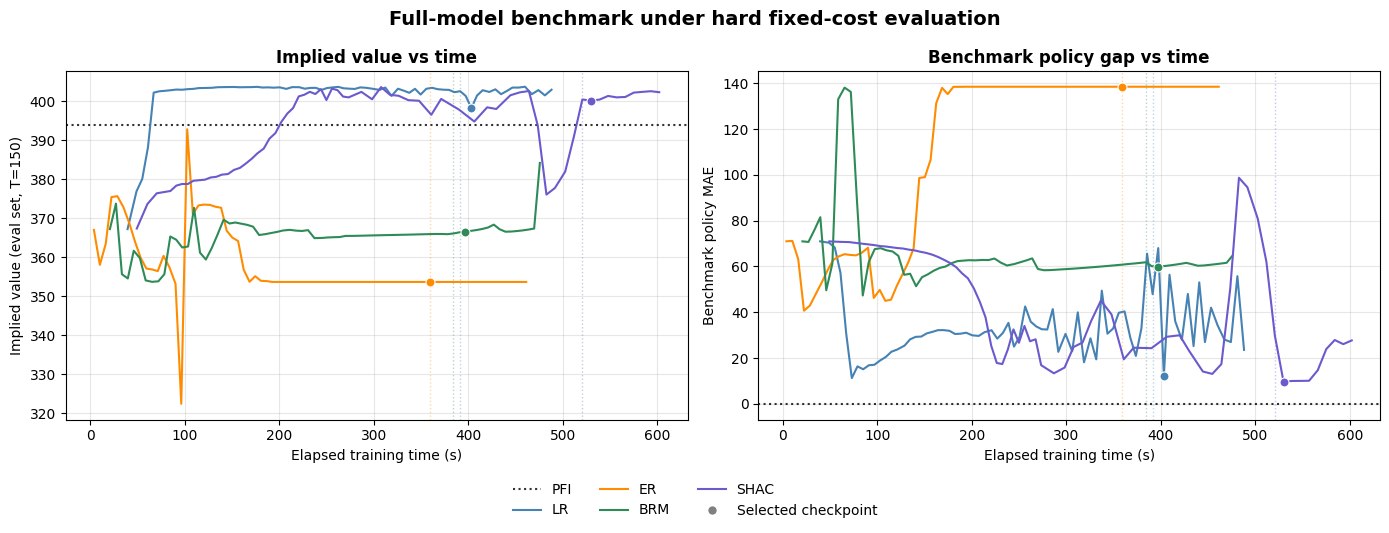

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes = np.atleast_1d(axes)
legend_handles = []
legend_labels = []
selected_handle = Line2D(
    [0], [0], marker="o", color="none",
    markerfacecolor="gray", markeredgecolor="white",
    markersize=7, label="Selected checkpoint",
)

ax = axes[0]
pfi_line = ax.axhline(pfi_value, color="black", lw=1.5, ls=":", alpha=0.8)
legend_handles.append(pfi_line)
legend_labels.append("PFI")
for name in METHOD_ORDER:
    entry = results[name]
    m = entry["checkpoint_metrics"]
    (line,) = ax.plot(m["elapsed_sec"], m["implied_value"], color=METHOD_COLORS[name], lw=1.5)
    add_anneal_marker(ax, entry)
    add_selected_marker(ax, entry, "implied_value")
    legend_handles.append(line)
    legend_labels.append(name)
ax.set_xlabel("Elapsed training time (s)")
ax.set_ylabel(f"Implied value (eval set, T={EVAL_HORIZON})")
ax.set_title("Implied value vs time", fontweight="bold")
ax.grid(True, alpha=0.3)

ax = axes[1]
for name in METHOD_ORDER:
    entry = results[name]
    m = entry["checkpoint_metrics"]
    ax.plot(m["elapsed_sec"], m["benchmark_policy_mae"], color=METHOD_COLORS[name], lw=1.5)
    add_anneal_marker(ax, entry)
    add_selected_marker(ax, entry, "benchmark_policy_mae")
ax.axhline(0.0, color="black", lw=1.5, ls=":", alpha=0.8)
ax.set_xlabel("Elapsed training time (s)")
ax.set_ylabel("Benchmark policy MAE")
ax.set_title("Benchmark policy gap vs time", fontweight="bold")
ax.grid(True, alpha=0.3)

fig.legend(
    legend_handles + [selected_handle],
    legend_labels + ["Selected checkpoint"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
)
fig.suptitle("Full-model benchmark under hard fixed-cost evaluation", fontweight="bold", fontsize=14)
plt.tight_layout(rect=(0, 0.08, 1, 1))
persist_figure(fig, "convergence_curves.png")
plt.show()


## 7.2 Selected Checkpoint Validation

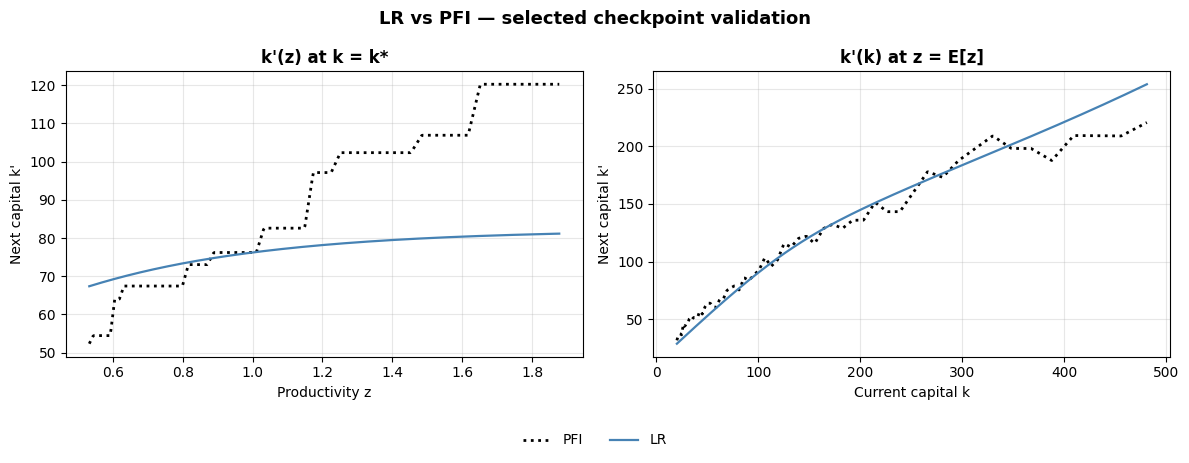

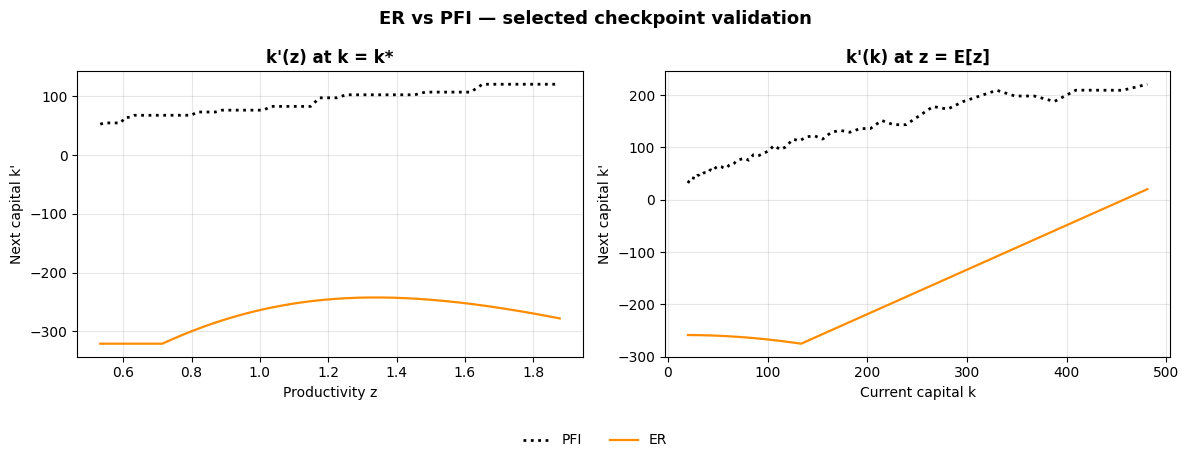

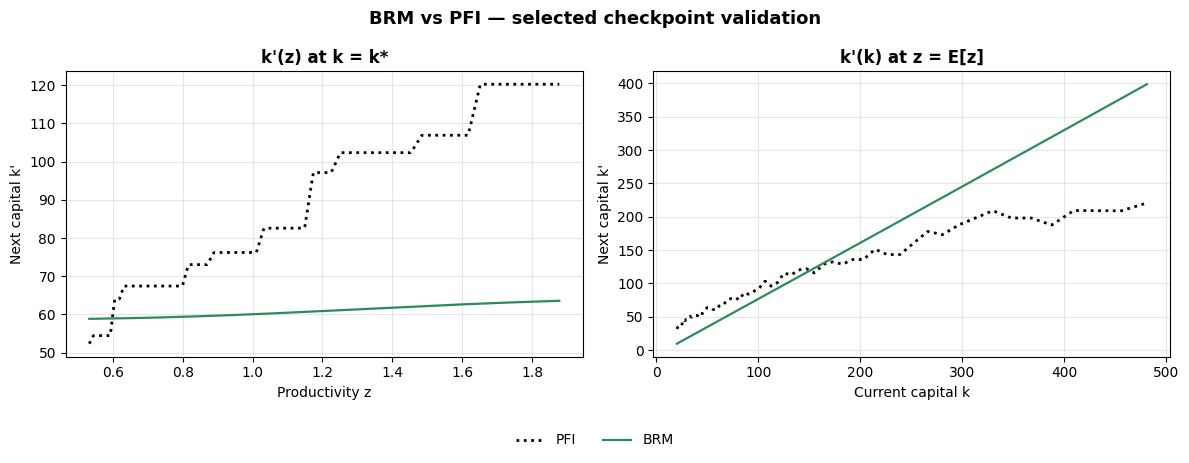

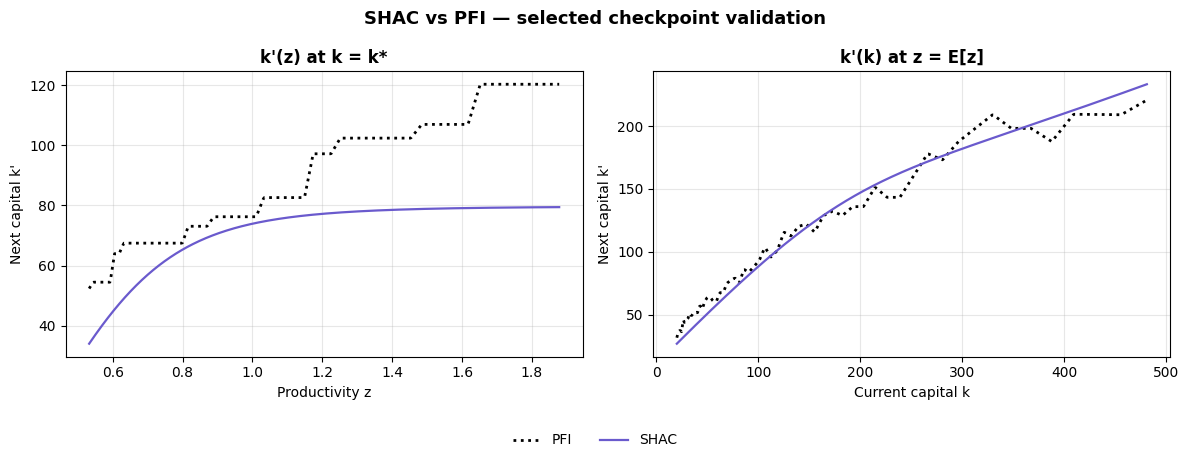

In [14]:
pfi_kpz, pfi_kpk = get_policy_slices(pfi_policy)

for name in METHOD_ORDER:
    policy = results[name]["policy"]
    kp_z, kp_k = get_policy_slices(policy)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(z_grid, pfi_kpz, color=METHOD_COLORS["PFI"], lw=2.0, ls=":", label="PFI")
    axes[0].plot(z_grid, kp_z, color=METHOD_COLORS[name], lw=1.6, label=name)
    axes[0].set_title("k'(z) at k = k*", fontweight="bold")
    axes[0].set_xlabel("Productivity z")
    axes[0].set_ylabel("Next capital k'")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(k_grid, pfi_kpk, color=METHOD_COLORS["PFI"], lw=2.0, ls=":", label="PFI")
    axes[1].plot(k_grid, kp_k, color=METHOD_COLORS[name], lw=1.6, label=name)
    axes[1].set_title("k'(k) at z = E[z]", fontweight="bold")
    axes[1].set_xlabel("Current capital k")
    axes[1].set_ylabel("Next capital k'")
    axes[1].grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=2,
        frameon=False,
    )
    fig.suptitle(
        f"{name} vs PFI — selected checkpoint validation",
        fontweight="bold",
        fontsize=13,
    )
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    persist_figure(fig, f"policy_slices_{name.lower()}.png")
    plt.show()


## 7.3 Selected Checkpoints Overlay

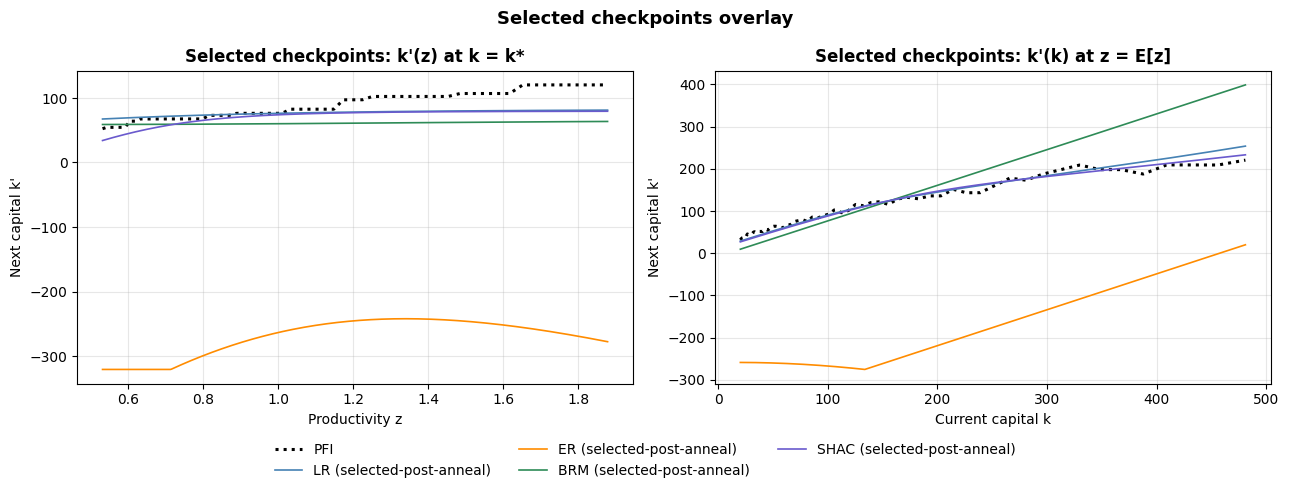

In [15]:
pfi_kpz, pfi_kpk = get_policy_slices(pfi_policy)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(z_grid, pfi_kpz, color=METHOD_COLORS["PFI"], lw=2.2, ls=":", label="PFI")
for name in METHOD_ORDER:
    kp_z, _ = get_policy_slices(results[name]["policy"])
    axes[0].plot(
        z_grid,
        kp_z,
        color=METHOD_COLORS[name],
        lw=1.2,
        label=f"{name} ({results[name]['selected']['status']})",
    )
axes[0].set_title("Selected checkpoints: k'(z) at k = k*", fontweight="bold")
axes[0].set_xlabel("Productivity z")
axes[0].set_ylabel("Next capital k'")
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_grid, pfi_kpk, color=METHOD_COLORS["PFI"], lw=2.2, ls=":", label="PFI")
for name in METHOD_ORDER:
    _, kp_k = get_policy_slices(results[name]["policy"])
    axes[1].plot(
        k_grid,
        kp_k,
        color=METHOD_COLORS[name],
        lw=1.2,
        label=f"{name} ({results[name]['selected']['status']})",
    )
axes[1].set_title("Selected checkpoints: k'(k) at z = E[z]", fontweight="bold")
axes[1].set_xlabel("Current capital k")
axes[1].set_ylabel("Next capital k'")
axes[1].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
)
fig.suptitle("Selected checkpoints overlay", fontweight="bold", fontsize=13)
plt.tight_layout(rect=(0, 0.08, 1, 1))
persist_figure(fig, "selected_checkpoints_overlay.png")
plt.show()


## 7.4 Summary Table

In [16]:
header = "Method | Status                | StopReason      | StopStep | SelStep | SelTime(s) | Value      | ValueGap   | Benchmark Policy MAE | Cost(s)"
print(header)
print("-" * len(header))

summary_rows = []

print(
    f"{'PFI':>6s} | {'benchmark':>21s} | {'benchmark':<15s} | {'-':>8s} | {'-':>7s} | {'-':>10s} | "
    f"{results['PFI']['selected']['selected_value']:10.4f} | {0.0:10.6f} | {0.0:20.6f} | {results['PFI']['selected']['wall_time_sec']:7.1f}"
)
summary_rows.append({
    "method": "PFI",
    "status": "benchmark",
    "stop_reason": "benchmark",
    "stop_step": None,
    "selected_step": None,
    "selected_time_sec": None,
    "implied_value": results['PFI']['selected']['selected_value'],
    "value_gap": 0.0,
    "benchmark_policy_mae": 0.0,
    "cost_sec": results['PFI']['selected']['wall_time_sec'],
})
for name in METHOD_ORDER:
    sel = results[name]['selected']
    print(
        f"{name:>6s} | {sel['status']:>21s} | {sel['stop_reason']:<15s} | {str(sel['stop_step']):>8s} | "
        f"{str(sel['selected_step']):>7s} | "
        f"{str(round(sel['selected_elapsed_sec'], 1)) if sel['selected_elapsed_sec'] is not None else '-':>10s} | "
        f"{sel['selected_value']:10.4f} | {sel['selected_value_gap']:10.6f} | "
        f"{sel['selected_benchmark_policy_mae']:20.6f} | {sel['wall_time_sec']:7.1f}"
    )
    summary_rows.append({
        "method": name,
        "status": sel["status"],
        "stop_reason": sel["stop_reason"],
        "stop_step": sel["stop_step"],
        "selected_step": sel["selected_step"],
        "selected_time_sec": sel["selected_elapsed_sec"],
        "implied_value": sel["selected_value"],
        "value_gap": sel["selected_value_gap"],
        "benchmark_policy_mae": sel["selected_benchmark_policy_mae"],
        "cost_sec": sel["wall_time_sec"],
    })

save_summary_rows(RUN, summary_rows, filename="summary.csv")


Method | Status                | StopReason      | StopStep | SelStep | SelTime(s) | Value      | ValueGap   | Benchmark Policy MAE | Cost(s)
---------------------------------------------------------------------------------------------------------------------------------------------
   PFI |             benchmark | benchmark       |        - |       - |          - |   393.9741 |   0.000000 |             0.000000 |   195.4
    LR |  selected-post-anneal | plateau         |     1584 |    1298 |      403.2 |   398.2320 |   4.257935 |            12.351557 |   488.1
    ER |  selected-post-anneal | plateau         |     1924 |    1508 |      358.9 |   353.6501 |  40.323914 |           138.536060 |   461.3
   BRM |  selected-post-anneal | plateau         |     1314 |    1080 |      396.5 |   366.5695 |  27.404602 |            59.925676 |   475.7
  SHAC |  selected-post-anneal | max_wall_time   |      528 |     464 |      529.9 |   400.1619 |   6.187866 |             9.670833 |   602.1


PosixPath('/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/docs/results/v2_04_benchmark_full_basic/20260318-221345/summary.csv')